In [11]:
import pandas as pd
df=pd.read_csv(r"C:\Users\HP\Downloads\student_habits_performance.csv")

In [12]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [13]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

(1000, 16)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
sns.set(style="whitegrid")

In [16]:
# df.isna()
df.isna().sum()
df=df.dropna()

In [17]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 909, dtype: bool

In [18]:
import warnings
warnings.filterwarnings("ignore")

In [19]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [20]:
df.describe(include="object")

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,909,909,909,909,909,909,909
unique,909,3,2,3,3,3,2
top,S1999,Male,No,Fair,High School,Good,No
freq,1,440,713,396,392,410,620


In [21]:
categorical_cols=['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation']
for col in categorical_cols:
    print(f"Value counts for {col}: \n {df[col].value_counts()}")

Value counts for student_id: 
 student_id
S1999    1
S1000    1
S1001    1
S1002    1
S1003    1
        ..
S1018    1
S1017    1
S1016    1
S1015    1
S1014    1
Name: count, Length: 909, dtype: int64
Value counts for gender: 
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
Value counts for part_time_job: 
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
Value counts for diet_quality: 
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
Value counts for parental_education_level: 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
Value counts for internet_quality: 
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
Value counts for extracurricular_participation: 
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


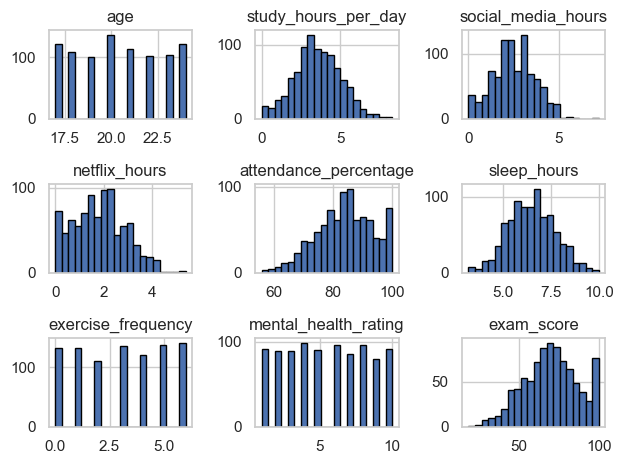

In [22]:
df.hist(bins=20,edgecolor="black")
plt.tight_layout()
plt.show()

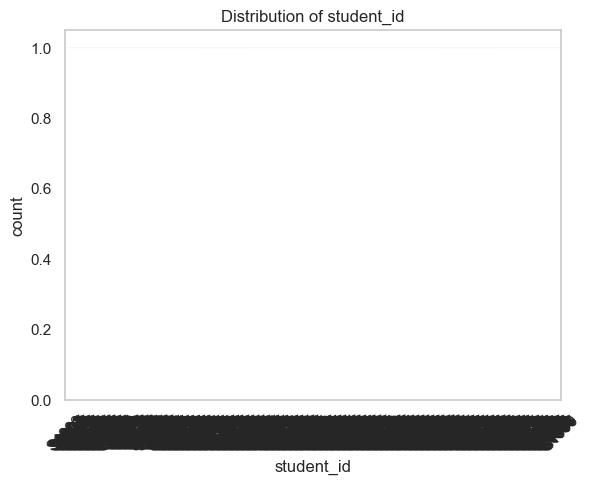

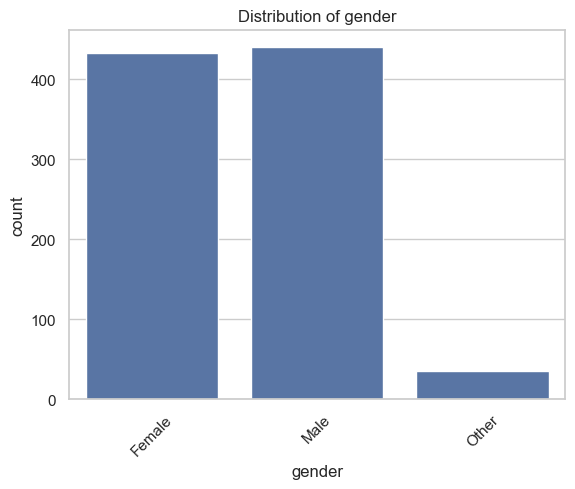

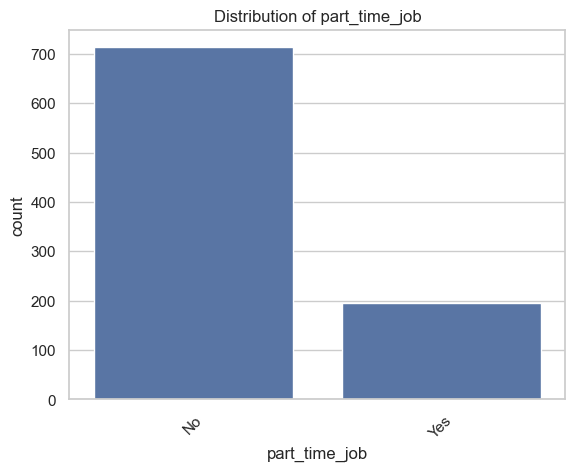

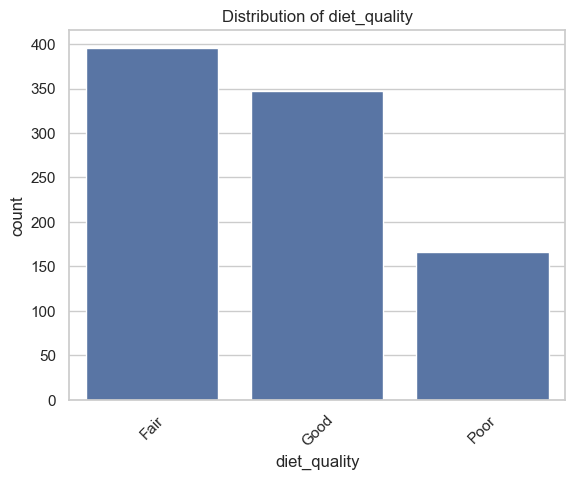

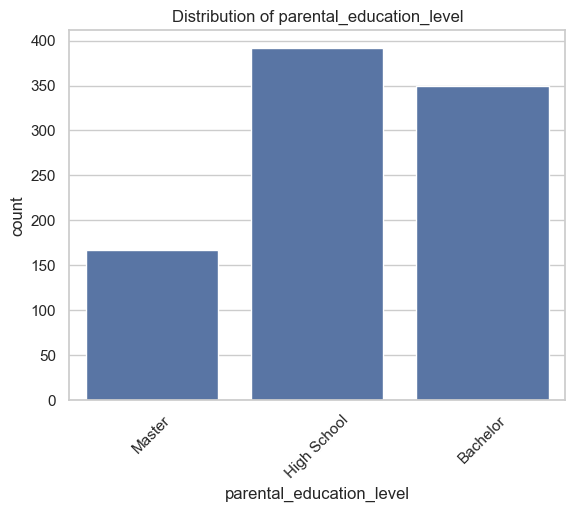

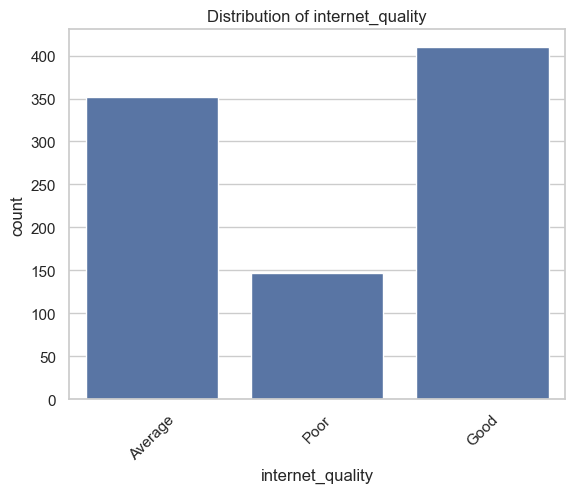

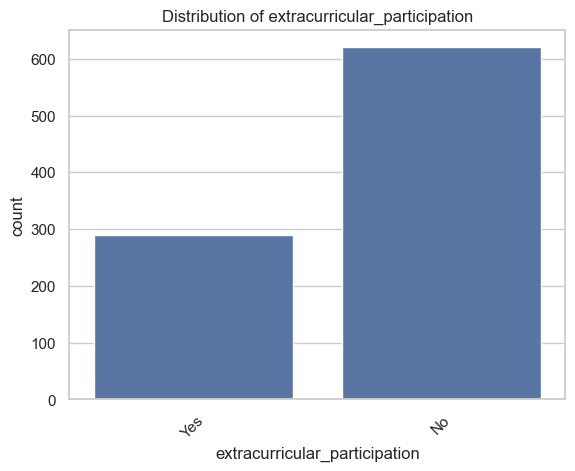

In [23]:
for col in categorical_cols:
    sns.countplot(data=df,x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

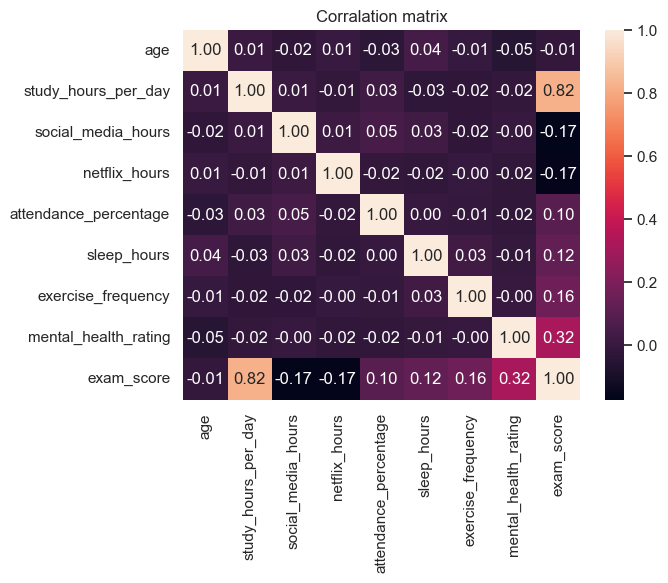

In [24]:
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f")
plt.title("Corralation matrix")
plt.show()

In [25]:
 df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

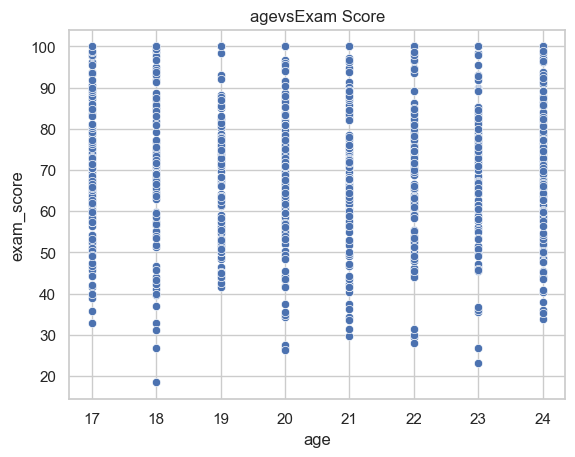

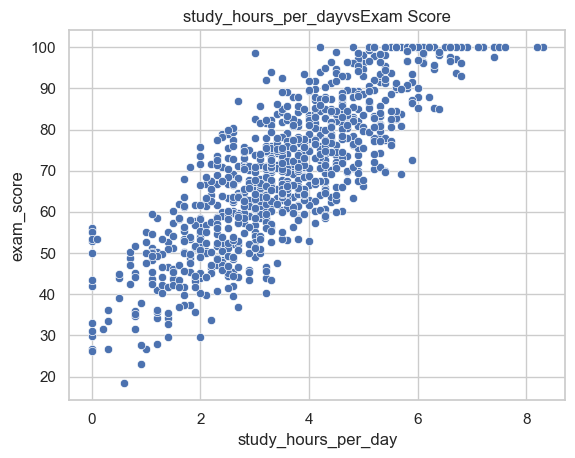

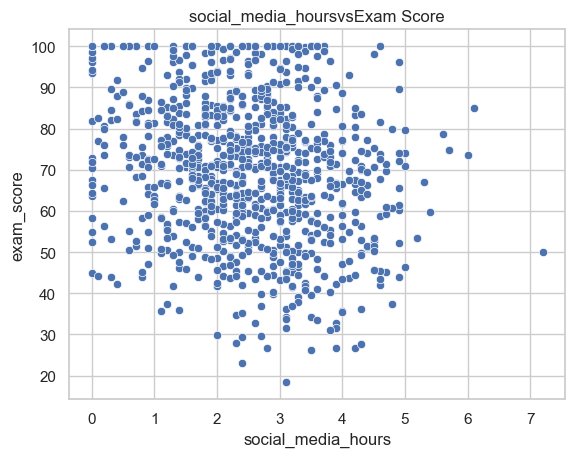

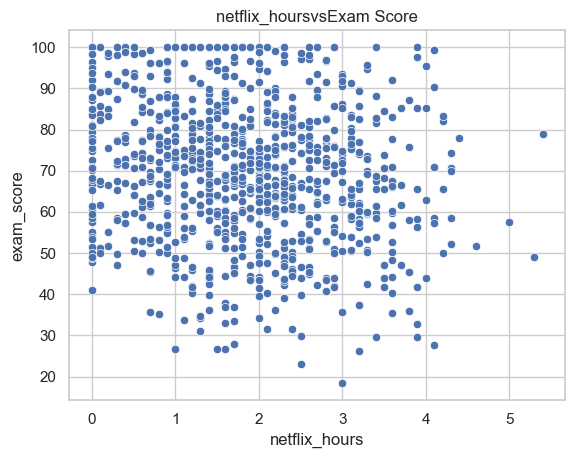

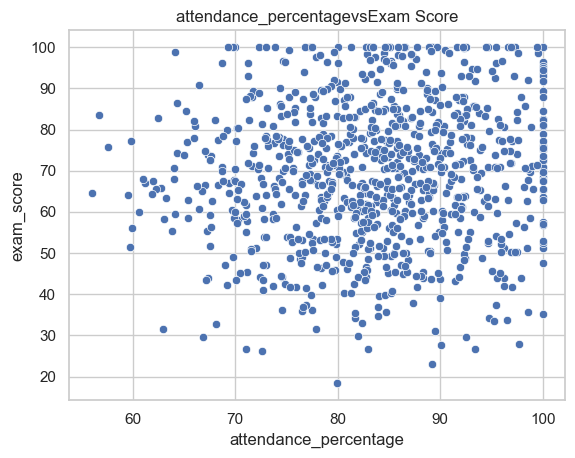

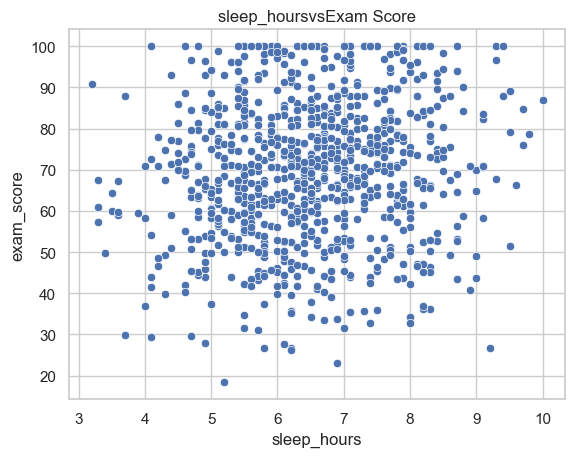

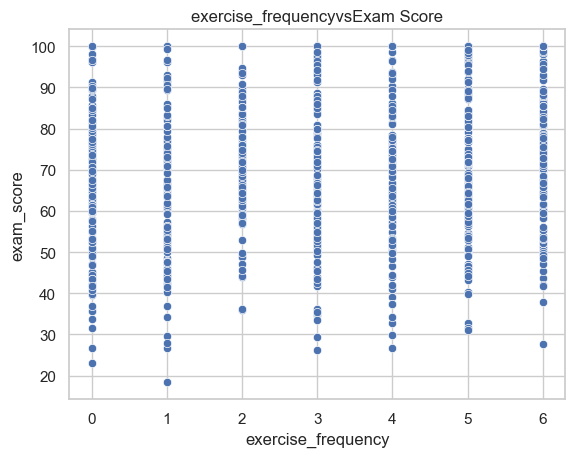

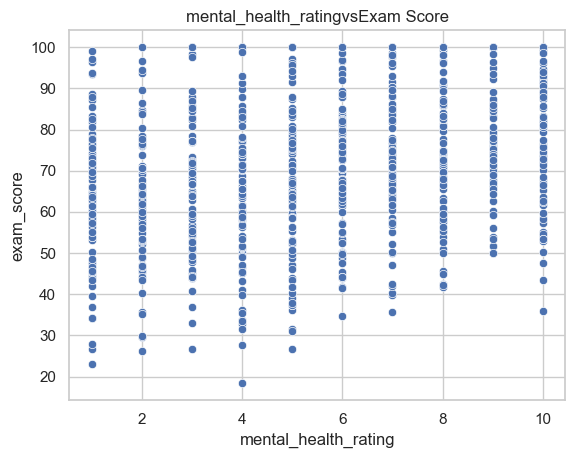

In [26]:
num_features=['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating']
for feature in num_features:
    sns.scatterplot(data=df,x=feature,y="exam_score")
    plt.title(f"{feature}vsExam Score")
    plt.show()

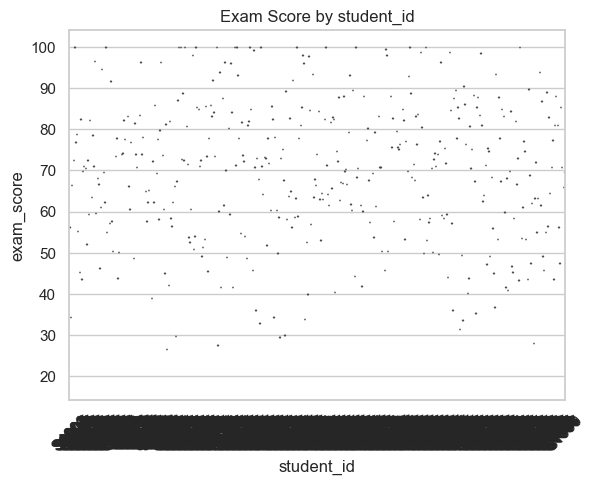

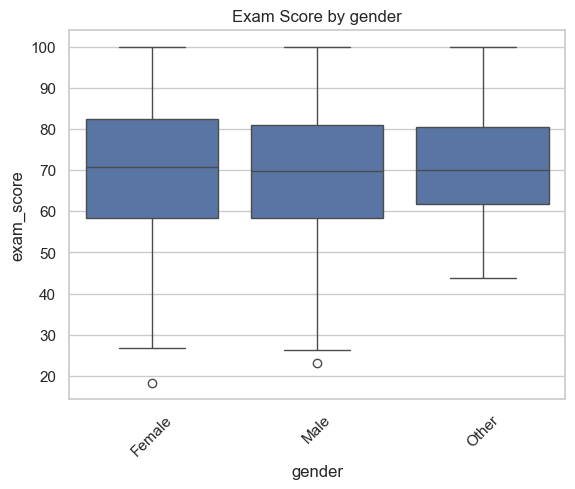

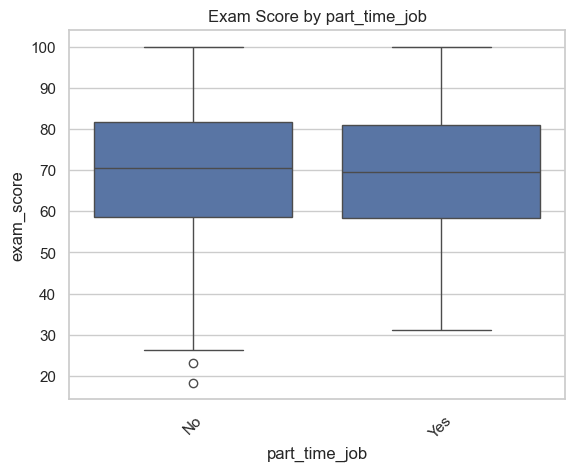

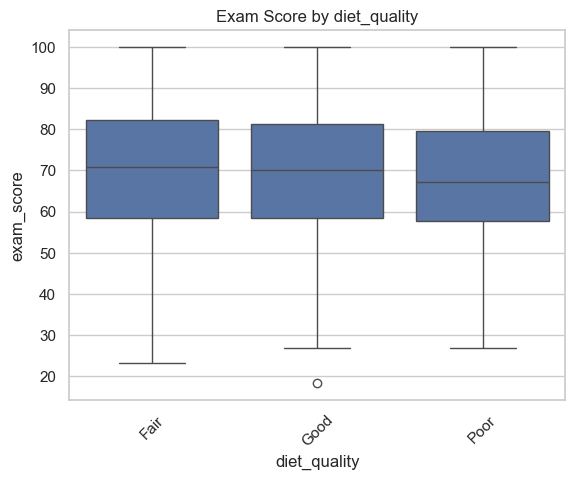

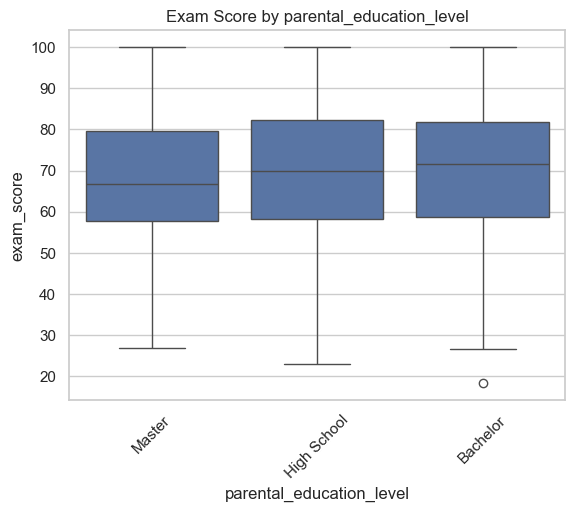

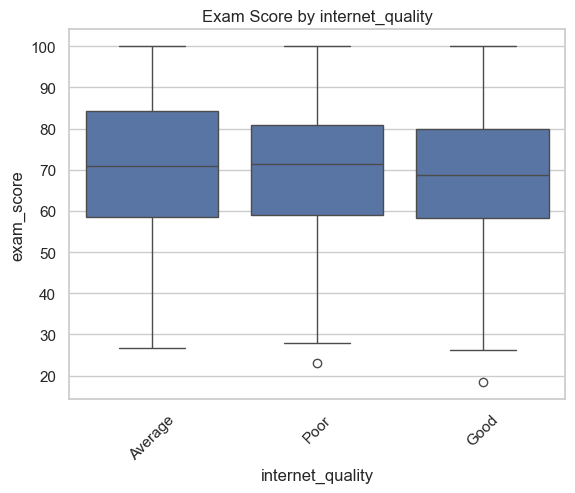

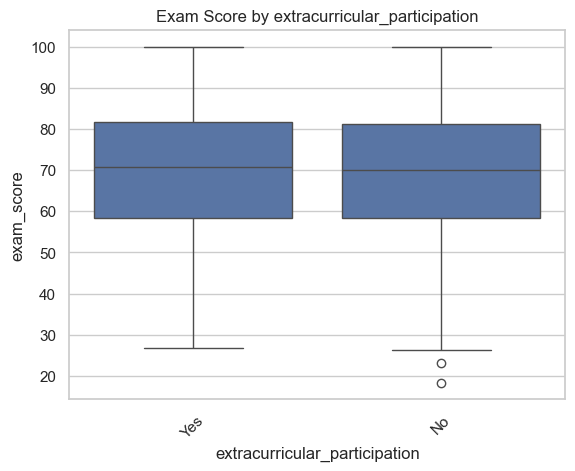

In [27]:
for col in categorical_cols:
    sns.boxplot(data=df,x=col,y="exam_score")
    plt.title(f"Exam Score by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [28]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor


In [29]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [30]:
df.head(2)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0


In [31]:
features=['study_hours_per_day','attendance_percentage','mental_health_rating','sleep_hours','part_time_job']

In [32]:
target="exam_score"

In [33]:
df_model=df[features+[target]].copy()
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,No,56.2
1,6.9,97.3,8,4.6,No,100.0
2,1.4,94.8,1,8.0,No,34.3
3,1.0,71.0,1,9.2,No,26.8
4,5.0,90.9,1,4.9,No,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,No,76.1
996,2.9,86.0,6,6.8,Yes,65.9
997,3.0,61.9,9,6.5,No,64.4
998,5.4,100.0,1,7.6,Yes,69.7


In [34]:
le=LabelEncoder()
# le.fit_transform(df_model["part_time_job"])
df_model["part_time_job"]= le.fit_transform(df_model["part_time_job"])
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,0,56.2
1,6.9,97.3,8,4.6,0,100.0
2,1.4,94.8,1,8.0,0,34.3
3,1.0,71.0,1,9.2,0,26.8
4,5.0,90.9,1,4.9,0,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,0,76.1
996,2.9,86.0,6,6.8,1,65.9
997,3.0,61.9,9,6.5,0,64.4
998,5.4,100.0,1,7.6,1,69.7


In [35]:
X=df_model[features]
Y=df_model[target]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)
len(Y_test)
len(Y_train)

727

In [36]:
models={
    "LinearRegression":{
        "model":LinearRegression(),
        "params":{}
    },
    "DecesionTree":{
        "model":DecisionTreeRegressor(),
        "params":{"max_depth":[3,5,6],"min_samples_split":[2,5]}
    },
     "RandomForest":{
        "model":RandomForestRegressor(),
        "params":{"n_estimators":[50,100],"max_depth":[5,10]}
     }
}

In [37]:
best_model=[]
for name, config in models.items():
    print(f"Training{name}")
    grid=GridSearchCV(config["model"],config["params"],cv=5,scoring="neg_mean_squared_error")
    grid.fit(X_train,Y_train)
    Y_pred=grid.predict(X_test)
    rmse=np.sqrt(mean_squared_error(Y_test,Y_pred))
    r2=r2_score(Y_test,Y_pred)
    best_model.append({
        "model":name,
        "best_params":grid.best_params_,
        "rmse":rmse,
        "r2":r2
    })


TrainingLinearRegression
TrainingDecesionTree
TrainingRandomForest


[{'model': 'LinearRegression',
  'best_params': {},
  'rmse': np.float64(7.993375349383243),
  'r2': 0.7907451535917966},
 {'model': 'DecesionTree',
  'best_params': {'max_depth': 5, 'min_samples_split': 5},
  'rmse': np.float64(9.393158814921124),
  'r2': 0.7110395253984618},
 {'model': 'RandomForest',
  'best_params': {'max_depth': 10, 'n_estimators': 100},
  'rmse': np.float64(8.348493727854143),
  'r2': 0.7717391858744672}]

In [38]:
results_df=pd.DataFrame(best_model)
results_df.sort_values(by="rmse")

,model,best_params,rmse,r2
0,LinearRegression,{},7.993375,0.790745
2,RandomForest,"{'max_depth': 10, 'n_estimators': 100}",8.348494,0.771739
1,DecesionTree,"{'max_depth': 5, 'min_samples_split': 5}",9.393159,0.711040


In [40]:
import joblib
best_row=results_df.sort_values(by="rmse").iloc[0]
best_row

model          LinearRegression
best_params                  {}
rmse                   7.993375
r2                     0.790745
Name: 0, dtype: object

In [42]:
final_model=best_model_config["model"]
final_model.predict(X_test)

NameError: name 'best_model_config' is not defined